# CS345 Fall 2025 Final Project
## Bowling, Riley and Harrelson, Kevin
Riley: Linear, K-nn, Perceptron, Results

Kevin: Load, SVM, Neural Network, Random Forests

### Data Description

The data used in this notebook is from the following link: https://www.kaggle.com/datasets/prince7489/mental-health-and-social-media-balance-dataset/data

This data is meant to be used to show various relationships between stress, overall happiness, social media, and some other metrics. It consists of 500 entries with little to no missing data. There are 9 features in this data set that were used for different purposes. The various features allowed for feature selection based on weight, which was used to determine which metrics had the largest impact on overall happiness. The final score, a happiness index, is a value ranging from 1 to 10, but the final goal of these models is to find which metric had the largest absolute impact on the happiness index.

### Methodology

The previously mentioned data was split so that 80% of it was used for training, and the other 20% was used for testing. This data was used in multiple different models to try to get the best understanding of our goal: find which metric had the largest absolute impact on the overall happiness index. These models include linear regression, K-nearest neighbor regression, stochastic gradient descent regression, 3 different support vector machine models, a neural network, and random forest regression. The support vector machine models varied by preprocessing standard: one standardizing all values, one only standardizing non-one-hot values, and one using principal component analysis.

The linear models were used to see the impact of each metric on the overall happiness index. This was shown through a sensitivity analysis that was able to calculate the mean coefficient and the standard deviation from this mean. This table was extremely helpful in seeing which metrics had the largest impact. Every model also reported on its general accuracy performance, including an R-squared value, the mean absolute error, and the mean standard error. Each model returns its best possible accuracy performance, and returns the hyperparameters that bred those results. These hyperparameters are tested and determined through grid searches.

In [2]:
import copy
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd
import shutil
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold, GridSearchCV, train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

pd.set_option('display.precision', 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
gloabl_random_seed = 31415

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

In [3]:
RUN_LINEAR_REGRESSION = True
RUN_KNN = True
RUN_SGD = True
RUN_SVR = True
RUN_NN = True
RUN_RANDOM_FOREST = True

# Load the Data
Also defines some useful functions.

In [4]:
def replace_columns(original, column_to_replace = None, new_columns = None) :
    if column_to_replace is not None :
        result = original.drop(column_to_replace, axis=1)
    if new_columns is not None :
        result = pd.concat([result, new_columns], axis=1)
    return result

def change_column(data, column_to_change) :
    column_data = data[[column_to_change]]
    ohe = OneHotEncoder(sparse_output=False)
    ohe.fit(column_data)
    new_columns = pd.DataFrame(ohe.transform(column_data), columns = ohe.get_feature_names_out(column_data.columns))
    data = replace_columns(data, column_to_change, new_columns)
    return data

def get_student_data():
    data = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
    X = data.iloc[:, 1:-1]
    y = data.iloc[:, -1]

    # Now we have the raw values.  Time to get it into a fit form for processing.
    X = change_column(X, "Gender")
    X = change_column(X, "Social_Media_Platform")
    columns = X.columns
    numeric_columns =columns[0:6]
    return X, y, numeric_columns, columns

X, y, numeric_columns, all_columns = get_student_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = gloabl_random_seed)

num_samples, num_features = X.shape


# Sensitivity Analysis

For this dataset, simple prediction of happiness is only the first step.  The ultimate goal should be on how to CHANGE a person's behavior to maximize happiness.  Because many models can be black boxes, the approach will be to do the following:

* Go through each target variable
    * Go through EACH element of the data set (all elements, not just the test set),
        * Take the target variable and run two predictions:
            * One prediction with the target variable increased by a small amount
            * One prediction with the target variable decreased by a small amount
            * Record the slope
    * Record the mean and standard deviation of the slopes

The final result should be general advice on which variables are the most important to increase and which ones should decrease.

Note that this is *GENERAL* advice.  There could be an optimum value for some variables, and the advice could be dependent on the particular case.  While this is certianly possible, personalized advice is not the goal of this project, and would result in too much data to easily digest.

We will also make the following assumptions:
* For "one hot" variables, they will all be set to 0.5 and then see if a change results in more or less happiness.
* We will then draw conclusions from the results.
    * For each feature we will predict how a change will impact happiness.



In [5]:
#####
# Common Stuff
####


#####
#  This is the directory that we will store the cache in.
#####
# Right now, only used for SVM.
cache_dir = 'c:/temp/final_project_cache'

# Run this next line if you make major changes and want to free up disk space.
# This is used by SVM.
#shutil.rmtree(cache_dir)
os.makedirs(cache_dir, exist_ok=True)

#####
#  This is the standard cv strategy that we should use, just to be consistent
#####
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=gloabl_random_seed)

def get_prediction(model, X):
    if isinstance(model, nn.Module):
        model.eval()
        y_pred = model(X).view(-1, 1)
        y_pred = y_pred.detach().cpu().numpy()
    else:
        y_pred = model.best_estimator_.predict(X)
    return y_pred

#####
#  Sensitivity Analysis Code
#####
def apply_delta_to_slope(model, X, column, delta):
    if isinstance(model, nn.Module):
        temp_X = X.clone()
        #print("*****")
        #print(f"all_columns: {type(all_columns)} =  {all_columns}")
        #print(f"column: {type(column)} =  {column}")
        #print(column)
        index = all_columns.get_loc(column)
        #print(f"index: {type(index)} =  {index}")
        #print(f"temp_X: {type(temp_X)} =  {temp_X}")
        temp_X[:, index] += delta
    else:
        temp_X = X.copy()
        temp_X[column] += delta
    y_pred = get_prediction(model, temp_X)
    return y_pred

def get_column_slope(model, X, column, auto_scale = False):
    delta = 0.01
    while True:
        y_pred_plus = apply_delta_to_slope(model, X, column, delta)
        y_pred_minus = apply_delta_to_slope(model, X, column, -delta)
        y_slope = (y_pred_plus - y_pred_minus) / delta

        if not auto_scale:
            break
        # If we get here then we MAY need to increase the delta to make sure that we get a slope.
        true_mask = (np.abs(y_slope) >= 0.001)
        num_true = np.sum(true_mask)
        ratio_sloped = num_true/ len(y_slope)
        #print(f"Slope ratio: {ratio_sloped}")
        if ratio_sloped > 0.95 : # At least 95% of all samples must have a slope.  Else increase delta.
            break
        delta *= 1.2
        if delta > 1 : # We have reached the limit of what we can do.
            break
    return ([np.mean(y_slope),np.std(y_slope)])


def sensitivity_analysis(model_name, model, X, y, all_columns, auto_scale = False):
    #####
    # First, modify the X data
    #####
    if isinstance(model, nn.Module) :
        ## NN CODE PATH
        temp_X = X.clone()
    else:
        ## SCILEARNKIT CODE PATH.
        temp_X = X.copy()

    for i in range(len(all_columns)):
        ## This is not the optimal way to do things in a data frame, but this is generic to also work in PyTorch.
        this_column = all_columns[i]
        if this_column not in numeric_columns:
            if isinstance(model, nn.Module) :
                temp_X[:, i] = 0.5
            else :
                temp_X.iloc[:, i] = 0.5

    #####
    # Second, calculate each column.
    #####
    delta = 0.01
    results=[]
    for column in all_columns :
        results.append(get_column_slope(model, temp_X, column, auto_scale = auto_scale))

    #####
    # Convert results to Pandas series and return
    #####
    return pd.DataFrame(results, index = all_columns, columns = ["mean", "std_dev"])



def print_results(model_name, model,  X_test, y_test, X, y, include_sensitivity=True, auto_scale=False ) :
    #y_pred = model.best_estimator_.predict(X_test)
    y_pred = get_prediction(model, X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    if isinstance(model, nn.Module) :
        print(f"Model {model_name} results are: MAE={mae:.2f}, MSE={mse:.2f}, R-squared={r2:.4f}")
    else :
        print(f"Model {model_name} results are: MAE={mae:.2f}, MSE={mse:.2f}, R-squared={r2:.4f}\n using parameters {model.best_params_}")
    if include_sensitivity :
        print("Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).")
        sensitivity = sensitivity_analysis(model_name, model, X, y, all_columns, auto_scale=auto_scale)
        print(sensitivity)
        return sensitivity


# Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression

if RUN_LINEAR_REGRESSION:
    # Remove the scaler
    lr_pipeline = LinearRegression()

    lr_param_grid = [
        {'fit_intercept': [True, False]}
    ]

    lr_model = GridSearchCV(
        estimator=lr_pipeline,
        param_grid=lr_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=0,
        n_jobs=-1
    )

    lr_model.fit(X_train, y_train)
    lr_sensitivity = print_results("Linear Regression", lr_model, X_test, y_test, X, y)

Model Linear Regression results are: MAE=0.67, MSE=0.66, R-squared=0.5852
 using parameters {'fit_intercept': True}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean      std_dev
Age                                0.01647  7.19817e-14
Daily_Screen_Time(hrs)            -0.17399  4.96678e-14
Sleep_Quality(1-10)                0.63015  3.25400e-14
Stress_Level(1-10)                -1.01909  3.94111e-14
Days_Without_Social_Media          0.03460  5.11180e-14
Exercise_Frequency(week)           0.02698  3.23102e-14
Gender_Female                     -0.14940  6.53748e-14
Gender_Male                       -0.09270  6.38686e-14
Gender_Other                       0.24210  1.42674e-14
Social_Media_Platform_Facebook     0.12984  5.76142e-14
Social_Media_Platform_Instagram   -0.20067  7.04746e-14
Social_Media_Platform_LinkedIn    -0.02081  3.45596e-14
Social_Media_Platform_TikTok      -0.20466  8.04248e-14
Soci

### Linear Regression Results

In this experiment, the linear regression model produced moderate results with a R-sqaured values of .5852 and a mean absolute error of .67. This model also showed that the best result comes from fitting the intercept. With this information we are able to gather that there is about a 59% variance in mental health outcomes. 

With a negative coefficient of -1.01909, stress level came out to be the most impactful predictor in overall happiness. Following this, sleep quality had the strongest positive coefficient of .63015, showing its positive impact on mental health. Various social medias also had notable impacts, with Instagram, TikTok, and Youtube causing a negative impact while the others were positive. LinkedIn, age, and exercise frequency did not have much impact, and are likely non-linear relationships that could not be captured by a linear model. 

# K-nn

In [7]:
if RUN_KNN:

    knn_standardize_all_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor())
    ],
    memory=cache_dir
    )
    knn_standardize_all_estimator = TransformedTargetRegressor(
        regressor=knn_standardize_all_pipeline,
        transformer=StandardScaler()
    )
    knn_standardize_all_param_grid = {
        'regressor__knn__n_neighbors': [3, 5, 7, 10, 15, 20, 30],
        'regressor__knn__weights': ['uniform', 'distance'],
        'regressor__knn__metric': ['euclidean', 'manhattan']
    }

    knn_standardize_all_model = GridSearchCV(
        estimator=knn_standardize_all_estimator,
        param_grid=knn_standardize_all_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=0,
        n_jobs=-1
    )
    knn_standardize_all_model.fit(X_train, y_train)
    knn_sensitivity = print_results("KNN Standardize all", knn_standardize_all_model, X_test, y_test, X, y, include_sensitivity = True)

Model KNN Standardize all results are: MAE=0.77, MSE=0.83, R-squared=0.4841
 using parameters {'regressor__knn__metric': 'manhattan', 'regressor__knn__n_neighbors': 15, 'regressor__knn__weights': 'distance'}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean  std_dev
Age                               -0.05146  1.28022
Daily_Screen_Time(hrs)            -0.26860  3.29984
Sleep_Quality(1-10)                0.37021  2.83519
Stress_Level(1-10)                -0.33774  2.85516
Days_Without_Social_Media          0.18047  2.52020
Exercise_Frequency(week)          -0.11386  2.77862
Gender_Female                      0.02871  5.85201
Gender_Male                       -0.05587  5.73213
Gender_Other                      -0.10961  3.66741
Social_Media_Platform_Facebook    -0.15346  4.65515
Social_Media_Platform_Instagram   -0.41623  4.08860
Social_Media_Platform_LinkedIn    -0.07468  5.30660
Social_Media_Platfor

### K-nn Results

In comparison to linear regression, this model achieved a lower performance with an R-squared value of .4841. Along with this, the KNN model resulted in a mean absolute error of .77. The best model had 15 neighbors and distanced based weighting.

Since the KNN model is non-parametric, it made the sensitvity analysis a bit challenging. As shown by the high standard deviations, this model creates unstable slopes and unreliable values. KNN uses an instance based learning approach, meaning that it takes in the K most similar data points, averages the outcomes, and creates a step function. Other than this, the model was still able to find optimal hyperparameters to maximize performance.

# SGD Regression

In [8]:
from sklearn.linear_model import SGDRegressor
# for convergence warnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

if RUN_SGD:
    sgd_standardize_all_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('sgd', SGDRegressor(random_state=gloabl_random_seed))
        ],
        memory=cache_dir
        )
    
    sgd_standardize_all_estimator = TransformedTargetRegressor(
        regressor=sgd_standardize_all_pipeline,
        transformer=StandardScaler()
    )
    
    sgd_standardize_all_param_grid = {
        'regressor__sgd__penalty': [None, 'l2', 'l1', 'elasticnet'],
        'regressor__sgd__alpha': [0.0001, 0.001, 0.01, 0.1],
        'regressor__sgd__max_iter': [1000, 2000, 5000],
        'regressor__sgd__tol': [1e-3, 1e-4, 1e-5],
        'regressor__sgd__eta0': [0.1, 1.0, 10.0],
        'regressor__sgd__learning_rate': ['constant', 'optimal', 'invscaling']
    }
    
    sgd_standardize_all_model = GridSearchCV(
        estimator=sgd_standardize_all_estimator,
        param_grid=sgd_standardize_all_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=0,
        n_jobs=-1
    )
    
    sgd_standardize_all_model.fit(X_train, y_train)
    sgd_sensitivity = print_results("SGDRegressor Standardize all", sgd_standardize_all_model, X_test, y_test, X, y, include_sensitivity=True)

Model SGDRegressor Standardize all results are: MAE=0.66, MSE=0.65, R-squared=0.5966
 using parameters {'regressor__sgd__alpha': 0.1, 'regressor__sgd__eta0': 0.1, 'regressor__sgd__learning_rate': 'optimal', 'regressor__sgd__max_iter': 1000, 'regressor__sgd__penalty': 'l2', 'regressor__sgd__tol': 0.0001}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean      std_dev
Age                                0.01563  7.47810e-14
Daily_Screen_Time(hrs)            -0.00286  7.41528e-14
Sleep_Quality(1-10)                0.75046  7.47918e-14
Stress_Level(1-10)                -1.03357  7.18184e-14
Days_Without_Social_Media          0.03556  6.19579e-14
Exercise_Frequency(week)           0.04803  4.98884e-14
Gender_Female                     -0.05063  7.50027e-14
Gender_Male                       -0.00981  7.38373e-14
Gender_Other                       0.36998  3.58151e-14
Social_Media_Platform_Facebook     0.14

### SGD Regression Results

As for the SGD regression model, it performed better than both the KNN and the linear regression models. The perceptron model was able to explain almost 60% of the variance in mental health outcomes with an R-squared value of .5966. Using an l2 penalty and an alpha value of .1 over 1000 iterations at an optimal learning rate, the SGD regressor was able to compute its best results.

In the sensitivity analysis, we are able to see that stress level had the largest impact overall (\~1.03) while sleep quality had the largest positive impact (\~.75). Shockingly, X/Twitter usage, along with Facebook usage, actually had positive coefficients, meaning they did not have a negative impact on overall happiness. All of the other social media sites had a negative coefficient, showing their true impact on mental health. 

# Support Vector Regression
I will try multiple kernels as well as using standardization and PCA.

In [9]:
##########
#  SVR standard stuff
##########

svr_standard_c = list(np.logspace(-1, 2, 4))
svr_standard_epsilon = list(np.logspace(-3, 0, 4))

## SVR, Standardize all numeric columns and output.
Technically, you are not supposed to standardize the "one-hot" features.  But we will try anyway, just to see what happens.

In [10]:
if RUN_SVR :
    svr_standardize_all_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ],
    memory=cache_dir
    )

    svr_standardize_all_estimator = TransformedTargetRegressor(
        regressor=svr_standardize_all_pipeline,
        transformer=StandardScaler()
    )

    svr_standardize_all_param_grid = [
        {
            # Parameters for 'linear' kernel
            'regressor__svr__kernel': ['linear'],
            'regressor__svr__C': svr_standard_c,
        },
        {
            # Parameters for 'rbf' (Radial Basis Function) kernel
            'regressor__svr__kernel': ['rbf'],
            'regressor__svr__C': svr_standard_c,
            'regressor__svr__gamma':  ['scale', 'auto'] + list(np.logspace(-3, 0, 7)),
        }
     ]

    svr_standardize_all_model = GridSearchCV(
        estimator=svr_standardize_all_estimator,
        param_grid=svr_standardize_all_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=0,  # Set to 1 for more info.
        n_jobs=-1 # Use as many cores as threads
    )
    svr_standardize_all_model.fit(X_train, y_train);
    svr_standardize_all_sensitivity = print_results("SVR Standardize all", svr_standardize_all_model, X_test, y_test, X, y)
    print("DONE")


Model SVR Standardize all results are: MAE=0.63, MSE=0.63, R-squared=0.6094
 using parameters {'regressor__svr__C': np.float64(100.0), 'regressor__svr__gamma': np.float64(0.001), 'regressor__svr__kernel': 'rbf'}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean  std_dev
Age                                0.01601  0.00624
Daily_Screen_Time(hrs)            -0.14331  0.12347
Sleep_Quality(1-10)                0.63410  0.13171
Stress_Level(1-10)                -1.06163  0.15206
Days_Without_Social_Media          0.01636  0.04302
Exercise_Frequency(week)           0.02267  0.02579
Gender_Female                     -0.03344  0.09059
Gender_Male                       -0.15965  0.06010
Gender_Other                       0.45257  0.26482
Social_Media_Platform_Facebook     0.01573  0.08179
Social_Media_Platform_Instagram   -0.35252  0.06470
Social_Media_Platform_LinkedIn     0.17261  0.12792
Social_Media_Pla

## SVR Standardize all but one-hot.
Now we will only standardize the stuff that is supposed to be standardized -- skipping the one-hot features.

In [11]:
if RUN_SVR:
    svr_standardize_some_preprocessor = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), numeric_columns)],
        remainder='passthrough',
    )

    svr_standardize_some_pipeline = Pipeline([
        ('svr_standardize_some_preprocessor', svr_standardize_some_preprocessor ),
        ('svr', SVR())
    ],
    memory=cache_dir
    )

    svr_standardize_some_estimator = TransformedTargetRegressor(
        regressor=svr_standardize_some_pipeline,
        transformer=StandardScaler()
    )

    svr_standardize_some_param_grid = [
        {
            # Parameters for 'linear' kernel
            'regressor__svr__kernel': ['linear'],
            'regressor__svr__C': svr_standard_c,
        },
        {
            # Parameters for 'rbf' (Radial Basis Function) kernel
            'regressor__svr__kernel': ['rbf'],
            'regressor__svr__C': svr_standard_c,
            'regressor__svr__gamma':  ['scale', 'auto'] + list(np.logspace(-3, 0, 7)),
        }
     ]

    svr_standardize_some_model = GridSearchCV(
        estimator=svr_standardize_some_estimator,
        param_grid=svr_standardize_some_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=0,  # Set to 1 for more info.
        n_jobs=-1 # Use as many cores as threads
    )
    svr_standardize_some_model.fit(X_train, y_train);
    svr_standardize_some_sensitivity = print_results("SVR Standardize some", svr_standardize_some_model, X_test, y_test, X, y)


Model SVR Standardize some results are: MAE=0.59, MSE=0.54, R-squared=0.6638
 using parameters {'regressor__svr__C': np.float64(1.0), 'regressor__svr__gamma': np.float64(0.01), 'regressor__svr__kernel': 'rbf'}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean  std_dev
Age                                0.01218  0.00645
Daily_Screen_Time(hrs)            -0.27397  0.11235
Sleep_Quality(1-10)                0.53571  0.11925
Stress_Level(1-10)                -0.92174  0.14458
Days_Without_Social_Media          0.01146  0.03813
Exercise_Frequency(week)           0.03835  0.04133
Gender_Female                      0.02199  0.02365
Gender_Male                       -0.06356  0.01702
Gender_Other                       0.01802  0.02672
Social_Media_Platform_Facebook    -0.00622  0.02647
Social_Media_Platform_Instagram   -0.20983  0.01346
Social_Media_Platform_LinkedIn     0.09490  0.03143
Social_Media_Platf

## SVR with PCA
In the previous experiment, skipping standardization on one-hot columns worked somewhat better.  But I want to be able to try a polynomial kernel.  The point of PCA is to reduce dimensions.  So I will standardize ALL columns and then use PCA to get the number of features down to a small enough amount to use "poly."  If I didn't use PCA on the one-hot columns, then there would be way too many dimensions to use a polynomial kernel.

In [12]:
if RUN_SVR:
    svr_pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=gloabl_random_seed)),
        ('svr', SVR())
    ],
    memory=cache_dir
    )

    svr_pca_estimator = TransformedTargetRegressor(
        regressor=svr_pca_pipeline,
        transformer=StandardScaler()
    )

    svr_pca_param_grid = [
        {
            # Parameters for 'linear' kernel
            'regressor__pca__n_components': list(range(1, 7)),
            'regressor__svr__kernel': ['linear'],
            'regressor__svr__C': svr_standard_c,
        },
        {
            # Parameters for 'rbf' (Radial Basis Function) kernel
            'regressor__pca__n_components': list(range(1, 7)),
            'regressor__svr__kernel': ['rbf'],
            'regressor__svr__C': svr_standard_c,
            'regressor__svr__gamma':  ['scale', 'auto'] + list(np.logspace(-3, 0, 7)),
        },
        {
            # Parameters for 'poly' (polynomial) kernel
            'regressor__pca__n_components': list(range(1, 7)),
            'regressor__svr__kernel': ['poly'],
            'regressor__svr__degree': [2],
            'regressor__svr__C': svr_standard_c,
            'regressor__svr__gamma':  ['scale', 'auto'] + list(np.logspace(-3, 0, 7)),
        },
     ]

    svr_pca_model = GridSearchCV(
        estimator=svr_pca_estimator,
        param_grid=svr_pca_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=1,  # Set to 1 for more info.
        n_jobs=-1 # Use as many cores as threads
    )
    svr_pca_model.fit(X_train, y_train);
    svr_pca_sensitivity = print_results("SVR Standardize all", svr_pca_model, X_test, y_test, X, y)

# Best results are: {'regressor__pca__n_components': 6, 'regressor__svr__C': np.float64(100.0), 'regressor__svr__gamma': np.float64(0.001), 'regressor__svr__kernel': 'rbf'}


Fitting 5 folds for each of 456 candidates, totalling 2280 fits
Model SVR Standardize all results are: MAE=0.59, MSE=0.58, R-squared=0.6356
 using parameters {'regressor__pca__n_components': 6, 'regressor__svr__C': np.float64(100.0), 'regressor__svr__gamma': np.float64(0.001), 'regressor__svr__kernel': 'rbf'}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean  std_dev
Age                                0.00322  0.00207
Daily_Screen_Time(hrs)            -0.53339  0.13003
Sleep_Quality(1-10)                0.55840  0.13553
Stress_Level(1-10)                -0.58412  0.14485
Days_Without_Social_Media          0.04852  0.01896
Exercise_Frequency(week)          -0.00714  0.02494
Gender_Female                      0.03668  0.01464
Gender_Male                       -0.05520  0.02002
Gender_Other                       0.11459  0.11203
Social_Media_Platform_Facebook     0.15272  0.09924
Social_Media_Platform

### Support Vector Regression Results

For the first test utilizing SVR, the model standardized all of the input values, including one-hot features. This model came in last place in terms of all of the SVR models, with an R-squared value of .6094. This is not surprising, since standardizing one-hot features ruins the whole point of it being one-hot, and it messes with the entire algorithm. Using a parameter grid, this model was able to gather that it created the best results with a C value of 100, a gamma value of .001, and using a radial basis function kernel. This model was able to conclude that the absolute largest influence on happiness was stress levels, being contradicted by the metric with the most positive impact, sleep quality.

The second SVR model standardized all columns except those with one-hot features. Since this is how SVR is meant to be done, it outperformed both of the other SVM models with an R-squared value of .6638, meaning it was able to explain an impressive 66% of variance when it came to overall mental health outcomes. Thanks to parameter grids, this model was able to use a C value of 1 and a gamma value of .01 within a radial basis function kernel. This model, like others, showed that the strongest influence on overall happiness was stress level, with a coefficient of -.92174. Also like others, this model showed that sleep quality had the largest positive impact on happiness.

Finally, the third model SVR along with principal component analysis (PCA). While the performance was not as strong as the properly standardized SVM model, it was still able to perform well and result in an R-squared value of .6356. Using PCA, the model is able to first reduce dimensionality and noise by transforming a set of correlated feature into a smaller set of uncorrelated features. The SVR is then able to create a non-linear decision boundary that is used to balance between model complexity and prediction accuracy. This model was also able to narrow down its best parameters to 6 components, a C value of 100, a gamma value of .001, and a radial basis function kernel. For this model, the most impactful metric was time spent on LinkedIn, with a coefficient of .61944. Other than this, the metric with the largest negative impact was TikTok, which makes lots of sense since it is such a toxic platform. 

# Neural Network Regression

In [13]:
# for apple silicon
torch.set_default_device('cpu')

if RUN_NN:
    torch.manual_seed(gloabl_random_seed)

    def dataframe_to_device(dataframe, device):
        data_np = dataframe.to_numpy()
        data_tensor = torch.from_numpy(data_np)
        data_tensor = data_tensor.to(torch.float32)
        return data_tensor.to(device)

    #####
    # Further split the training data into train and validate.  Load the data into the GPU (if available)
    #####
    Xv_train, Xv_validate, yv_train, yv_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state = gloabl_random_seed)


    X_nn = dataframe_to_device(X, device)
    y_nn = dataframe_to_device(y, device)
    X_nn_train = dataframe_to_device(Xv_train, device)
    y_nn_train = dataframe_to_device(yv_train, device)
    X_nn_validate = dataframe_to_device(Xv_validate, device)
    y_nn_validate = dataframe_to_device(yv_validate, device)
    X_nn_test = dataframe_to_device(X_test, device)
    y_nn_test = dataframe_to_device(y_test, device)

    y_nn_validate_trans = y_nn_validate.view(-1, 1)
    y_nn_test_trans = y_nn_test.view(-1, 1) # Transpose



In [14]:
# Good example here: https://machinelearningmastery.com/building-a-regression-model-in-pytorch/
if RUN_NN:
   
    #####
    # Define a two-layer NN
    #####

    nn_inner_1_list = [3,4,6,8]
    nn_inner_2_list = [3,4,6,8]


    for nn_inner_1 in nn_inner_1_list:
        for nn_inner_2 in nn_inner_2_list:
            #print(f"Testing neural net with an architecture of {nn_inner_1}x{nn_inner_2}x1")
            torch.manual_seed(gloabl_random_seed)
            nn_model = nn.Sequential(
                nn.Linear(num_features, nn_inner_1),
                nn.ReLU(),
                nn.Linear(nn_inner_1, nn_inner_2),
                nn.ReLU(),
                nn.Linear(nn_inner_2, 1)
            )
            nn_model = nn_model.to(device)
            loss_fn = nn.MSELoss()  # mean square error
            optimizer = optim.Adam(nn_model.parameters(), lr=0.0001)

            # training parameters
            n_epochs = 100   # number of epochs to run
            batch_size = 10  # size of each batch
            batch_start = torch.arange(0, len(X_train), batch_size)

            # training parameters
            n_epochs = 500   # number of epochs to run
            batch_size = 10  # size of each batch
            batch_start = torch.arange(0, len(X_train), batch_size)

            # training loop
            best_mse = np.inf   # init to infinity
            best_weights = None
            history = []
            num_best = 0
            #print(f"Epoch:", end='')
            for epoch in range(n_epochs):
                #if epoch %10 ==0:
                #    print(f" {epoch}", end='')

                # Shuffle the data
                indices = torch.randperm(len(X_nn_train))
                X_nn_train_shuffle = X_nn_train[indices]
                y_nn_train_shuffle = y_nn_train[indices]

                # Do a training epoch
                nn_model.train()
                for start in batch_start:
                    # take a batch
                    X_batch = X_nn_train_shuffle[start:start+batch_size]
                    y_batch = y_nn_train_shuffle[start:start+batch_size]
                    y_batch = y_batch.view(-1, 1)
                    # forward pass
                    y_pred = nn_model(X_batch)
                    loss = loss_fn(y_pred, y_batch)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                # Check results
                nn_model.eval()
                y_pred = nn_model(X_nn_validate)
                mse = loss_fn(y_pred, y_nn_validate_trans).detach().item()
                mse = float(mse)
                history.append(mse)
                if mse < best_mse:
                    num_best = 0
                    best_mse = mse
                    best_weights = copy.deepcopy(nn_model.state_dict())
                else:
                    num_best += 1

                if num_best > 5 : # We have had five epochs without improvements.  Die
                    #print(f"\nFound best model.  No further improvements.", end='')
                    break
            #print()
            print_results(f"Neural Network {nn_inner_1}x{nn_inner_2}x1 trained for {epoch} epochs", nn_model, X_nn_test, y_nn_test, X_nn, y_nn, include_sensitivity=False)

    # nn_model.load_state_dict(best_weights)
    # plt.plot(history)
    # plt.show()
    # print_results("Neural Network", nn_model, X_nn_test, y_nn_test, X_nn, y_nn)

Model Neural Network 3x3x1 trained for 499 epochs results are: MAE=0.92, MSE=1.20, R-squared=0.2505
Model Neural Network 3x4x1 trained for 499 epochs results are: MAE=1.23, MSE=2.01, R-squared=-0.2527
Model Neural Network 3x6x1 trained for 499 epochs results are: MAE=0.99, MSE=1.37, R-squared=0.1441
Model Neural Network 3x8x1 trained for 499 epochs results are: MAE=0.88, MSE=1.18, R-squared=0.2658
Model Neural Network 4x3x1 trained for 499 epochs results are: MAE=2.67, MSE=8.45, R-squared=-4.2774
Model Neural Network 4x4x1 trained for 499 epochs results are: MAE=0.90, MSE=1.19, R-squared=0.2537
Model Neural Network 4x6x1 trained for 499 epochs results are: MAE=0.94, MSE=1.26, R-squared=0.2104
Model Neural Network 4x8x1 trained for 499 epochs results are: MAE=0.85, MSE=1.12, R-squared=0.3025
Model Neural Network 6x3x1 trained for 499 epochs results are: MAE=6.67, MSE=46.07, R-squared=-27.7770
Model Neural Network 6x4x1 trained for 499 epochs results are: MAE=1.09, MSE=1.67, R-squared=-0

### Neural Network Results

In comparison to other models, the neural network did not perform well. This model is severely overfitting the data, most likely because the data itself is limited. This is shown with the extreme negative R-squared values. This model was able to perform best with 8 neurons in the first hidden layer, 4 neurons in the second hidden layer, and one output neuron. After training for 499 epochs, the 8x4x1 model was able to achieve an R-squared value of .4114. This R-squared value is comparable with the KNN model (.484), but is still not as strong as the others. 

# Random Forest Regressor.

Note that the *sensitivity analysis* was difficult with this.

In [15]:
if RUN_RANDOM_FOREST:
    forest_preprocessor = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), numeric_columns)],
        remainder='passthrough',
    )

    forest_pipeline = Pipeline([
        ('forest_standardize_some_preprocessor', forest_preprocessor ),
        ('forest', RandomForestRegressor(n_estimators=20, random_state=gloabl_random_seed))
    ],
    memory=cache_dir
    )

    forest_estimator = TransformedTargetRegressor(
        regressor=forest_pipeline,
        transformer=StandardScaler()
    )

    forest_param_grid = [
        {
            # Parameters for 'linear' kernel
            'regressor__forest__n_estimators': [20, 40, 80],
            'regressor__forest__max_depth': [None, 10, 20],
            'regressor__forest__min_samples_split': [2, 5, 10],
            'regressor__forest__min_samples_leaf': [2, 5, 10],
        },
     ]

    forest_model = GridSearchCV(
        estimator=forest_estimator,
        param_grid=forest_param_grid,
        scoring='neg_mean_squared_error',
        cv=cv_strategy,
        verbose=1,  # Set to 1 for more info.
        n_jobs=-1 # Use as many cores as threads
    )
    forest_model.fit(X_train, y_train);

    random_forest_sensitivity = print_results("Random Forest", forest_model, X_test, y_test, X, y, auto_scale = True)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Model Random Forest results are: MAE=0.55, MSE=0.54, R-squared=0.6630
 using parameters {'regressor__forest__max_depth': None, 'regressor__forest__min_samples_leaf': 10, 'regressor__forest__min_samples_split': 2, 'regressor__forest__n_estimators': 80}
Sensitivity Analysis (predict how a change in a variable will result in a change in happiness).
                                      mean  std_dev
Age                                0.00692  0.02923
Daily_Screen_Time(hrs)            -0.38633  0.39218
Sleep_Quality(1-10)                0.39776  0.27183
Stress_Level(1-10)                -0.81649  0.47283
Days_Without_Social_Media          0.02904  0.07276
Exercise_Frequency(week)          -0.00337  0.08482
Gender_Female                     -0.00416  0.02027
Gender_Male                        1.74440  5.12980
Gender_Other                       0.00000  0.00000
Social_Media_Platform_Facebook    -0.00337  0.00470
Social_Media_Platf

### Random Forest Regressor Results

This model was able to perform very well with prediction. This random forest regressor was able to achieve an R-sqaured value of .6630, just barely falling behind the SVM model with one-hot encoding. On the other hand, this model does have a smaller mean absolute error than the SVM model with an MAE of .55.

In contrast to this, the sensitivity analysis struggled with this model because it is tree based and its step functions can make things a bit challenging. This is seen with the large discrepencies in the standard deviations along with the out-of-range mean for Gender_Male, and the 0 values for YouTube usage as well as Gender_Other. 

While this model struggled with feature importance and the estimates that come with it, it was able to excel at prediction with its impressive R-squared value. 

### Kevin - Use of AI and web resources

I needed help figuring out how to get the OneHotEncoder working.  This included errors when passing in a single column, as well as getting labels added to the output column data.

I needed help figuring out how to handle standardization in a pipeline, especially when using a "SearchCV" function.  The concept is easy, but the syntax is very Byzantine.  How to integrate PCA into a pipeline is far from obvious.  And since using scaling and PCA don't actually use all columns, I had to use a ColumnTransformer, which means using a sub-pipeline.  This stuff was not even really covered in class.  Knowing WHAT to do is actually easy.  Knowing the syntax of HOW to do it is quite confusing.

Searches were also needed in order to determine how to couple standardization of both X and Y values together in a grid search.  If we standardize X values, then we should also standardize Y values.

When doing PCA, is it normal to use PCA on one-hot or binary features?  I also asked an AI how to turn PCA off as an option for GridSearchCV.

I had to search to find out the best way to handle numeric results of operations on columns.  In other words, if doing a complex operation to get a result on each column, how can I put the data in a list with a column label attached.  It turns out the best choice is a dictionary, and then convert to a series at the end.



### Riley - Use of AI and web resources

When it comes to using AI in projects, especially for this class, I really only use it for more insight into things that I can't seem to be able to wrap my head around. In this project, I was able to utilize AI tools to help me understand why I was doing certain things in the code. I also used it to help me tweak our 'template' to still get the desired final result. I also was able to get some useful information on how to better format the final visual using AI. 

# Final Results Discussion

As you can see from the visual below, the category that had the largest absolute impact on overall happiness was stress level. This metric absolutely dominated all of the other features involved in the study. It even surprisingly had a larger impact than any of the social media usage. This goes to show how external stress can impact overall mental health more than one might think. This also goes to show that there may be some things that are thought to drastically improve overall happiness, like exercise and days without social media, really do very little. 

Our models were able to capture that age and excerise frequency per week had the smallest absolute impact on the overall happiness index. Along with this, the social media usage data varied a bit across each model but showed that X (Twitter) and Instagram had the largest impact while LinkedIn and Facebook had little impact. It was extremely useful to see this metric across so many models. If only one or a few were considered, one may have concluded that sleep quality had the largest impact, or the data concerning time spent on social media sites could have been skewed. As mentioned before, the KNN sensitivity data has not been included in the visual below, since it is a non-parametric model and the data is unreliable.

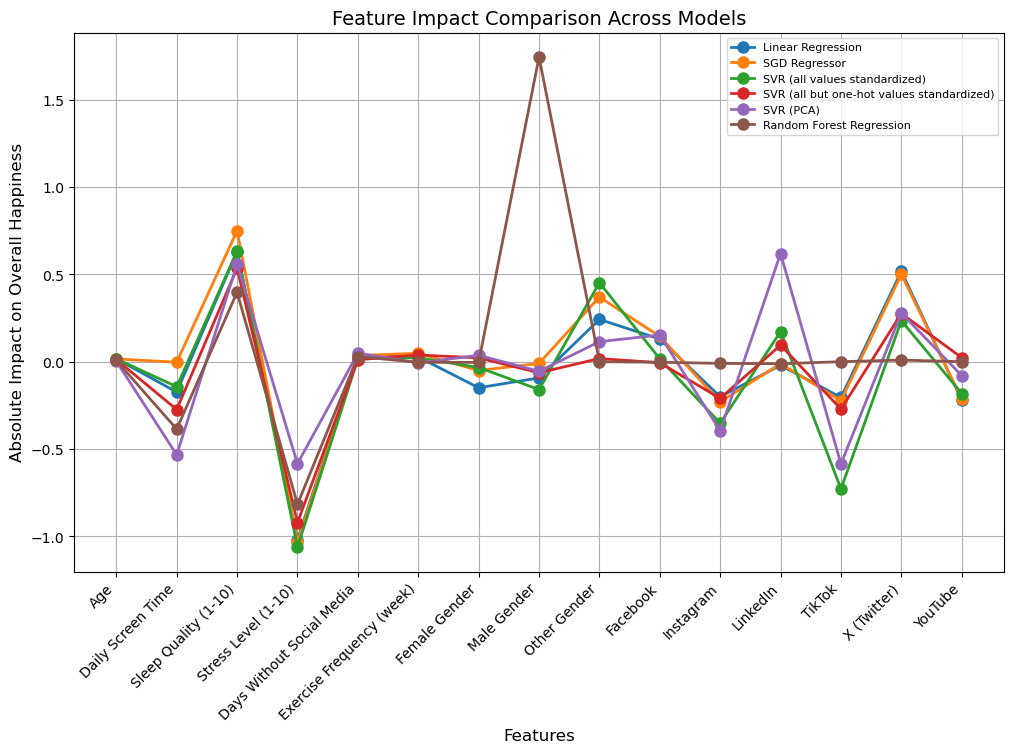

In [16]:
# final visual
features = ['Age', 'Daily Screen Time', 'Sleep Quality (1-10)', 'Stress Level (1-10)', 'Days Without Social Media', 
                'Exercise Frequency (week)', 'Female Gender', 'Male Gender', 'Other Gender', 'Facebook', 'Instagram', 'LinkedIn', 
               'TikTok','X (Twitter)', 'YouTube']
feature_positions = range(1, len(features) + 1)

plt.figure(figsize=(12, 7))
plt.plot(feature_positions, lr_sensitivity['mean'], marker='o', label='Linear Regression', linewidth=2, markersize=8)
#plt.plot(feature_positions, knn_sensitivity, marker='o', label='KNN', linewidth=2, markersize=8)
plt.plot(feature_positions, sgd_sensitivity['mean'], marker='o', label='SGD Regressor', linewidth=2, markersize=8)
plt.plot(feature_positions, svr_standardize_all_sensitivity['mean'], marker='o', label='SVR (all values standardized)', linewidth=2, markersize=8)
plt.plot(feature_positions, svr_standardize_some_sensitivity['mean'], marker='o', label='SVR (all but one-hot values standardized)', linewidth=2, markersize=8)
plt.plot(feature_positions, svr_pca_sensitivity['mean'], marker='o', label='SVR (PCA)', linewidth=2, markersize=8)
plt.plot(feature_positions, random_forest_sensitivity['mean'], marker='o', label='Random Forest Regression', linewidth=2, markersize=8)

plt.xticks(feature_positions, features, rotation=45, ha='right')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Absolute Impact on Overall Happiness", fontsize=12)
plt.title("Feature Impact Comparison Across Models", fontsize=14)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()